<a href="https://colab.research.google.com/github/innoted-latam/tp1_dne_uba/blob/main/TP1_PEREZ.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

```
ME72: Maestría en Métodos Cuantitativos para la Gestión y Análisis de Datos
M72109: Analisis de datos no estructurados
Universidad de Buenos Aires - Facultad de Ciencias Economicas (UBA-FCE)
Año: 2026
Estudiante: PÉREZ, LUCAS ENZO
```

## Preparación del ambiente

### NLP

In [9]:
!wget https://raw.githubusercontent.com/santiagxf/M72109/master/m72109/nlp/normalization.py \
    --quiet --no-clobber --directory-prefix ./m72109/nlp/
!wget https://raw.githubusercontent.com/santiagxf/M72109/master/m72109/nlp/transformation.py \
    --quiet --no-clobber --directory-prefix ./m72109/nlp/
!wget https://raw.githubusercontent.com/santiagxf/M72109/master/docs/nlp/neural/sequences-word2vec.txt \
    --quiet --no-clobber

In [10]:
!pip install -r sequences-word2vec.txt --quiet
!pip install datasets --quiet
!pip install transformers --quiet
!pip install unidecode --quiet
!python -m spacy download es_core_news_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 82.0 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


### Sets de datos

Descargamos el set de datos:

In [11]:
!wget https://raw.githubusercontent.com/santiagxf/M72109/refs/heads/master/Desafio/Data/ground_truth.csv --directory-prefix ./Data/ --quiet --no-clobber
!wget https://raw.githubusercontent.com/santiagxf/M72109/refs/heads/master/Desafio/Data/Features/caption_features.csv --directory-prefix ./Data/Features/ --quiet --no-clobber

Cargamos el set de datos:

In [12]:
import pandas as pd

labels = pd.read_csv('Data/ground_truth.csv')
cc = pd.read_csv('Data/Features/caption_features.csv', names=['sequence_name','cc'], header=0)

Los conjuntos de datos utilizados en este desafío son los siguientes:

*   `ground_truth.csv`: Contiene la verdad fundamental para el problema de clasificación. Este archivo incluye información sobre segmentos de video (`movie_name`, `start(sec)`, `end(sec)`) y su correspondiente puntuación de memorabilidad (`memorability_score`). **Aunque contiene varias columnas, para el problema de clasificación que abordaremos, la columna clave es `memorable`, que indica la probabilidad de que una persona recuerde el video.**
*   `caption_features.csv`: Contiene las características de las "captions" (descripciones textuales) asociadas a cada segmento de video. Cada segmento de video se identifica por `sequence_name` y cuenta con una descripción en la columna `cc`.

**Para proceder con el análisis, será necesario combinar estas etiquetas (`ground_truth.csv`) con las características (`caption_features.csv`).**

## Solución

In [13]:
# =============================================================================
# BLOQUE 1: CARGA, FUSIÓN DE DATOS Y DIAGNÓSTICO INICIAL
# =============================================================================
# Objetivo: construir la tabla analítica base del desafío, uniendo las etiquetas
# (ground truth) con las descripciones textuales de cada segmento de video, y
# validar la integridad del resultado antes de avanzar hacia el preprocesamiento
# de texto y el modelado.
# =============================================================================

# -----------------------------------------------------------------------------
# 0. Importación de librerías
# -----------------------------------------------------------------------------
import pandas as pd

# -----------------------------------------------------------------------------
# 1. CARGA DE DATOS
# -----------------------------------------------------------------------------
# 1.a) Etiquetas (ground truth). Contiene la identificación del segmento de
#      video, su puntaje continuo de memorabilidad ('memorability_score') y la
#      etiqueta binaria de clasificación ('memorable'), que es nuestro target.
labels_df = pd.read_csv('Data/ground_truth.csv')

# 1.b) Features de texto (captions). Se fuerzan explícitamente los nombres de
#      columna a ['sequence_name', 'cc'] mediante `names=...`, y se usa
#      `header=0` para indicarle a pandas que la primera fila del archivo es la
#      cabecera original y debe ser descartada (no interpretada como un dato).
#      Esto garantiza una nomenclatura estable y reproducible aunque cambien los
#      encabezados del archivo fuente.
captions_df = pd.read_csv(
    'Data/Features/caption_features.csv',
    names=['sequence_name', 'cc'],
    header=0
)

# -----------------------------------------------------------------------------
# 2. FUSIÓN DE DATOS (DATA MERGING)
# -----------------------------------------------------------------------------
# Se unen ambas fuentes por la clave primaria común 'sequence_name', que
# identifica unívocamente cada segmento de video.
# Se elige un INNER JOIN de forma deliberada: solo conservamos los segmentos que
# tienen simultáneamente etiqueta y descripción textual. Una observación sin
# target no es entrenable, y una sin texto no aporta features al modelo.
df_unificado = pd.merge(
    labels_df,
    captions_df,
    on='sequence_name',
    how='inner'
)

# -----------------------------------------------------------------------------
# 3. DIAGNÓSTICO DE INTEGRIDAD E INSPECCIÓN
# -----------------------------------------------------------------------------

# 3.a) Control de dimensiones (shape).
#      Comparamos las filas de origen contra las del resultado para detectar los
#      dos riesgos clásicos de un merge:
#        - PÉRDIDA de registros  -> filas resultantes < filas de origen
#          (claves que no matchean por typos, espacios o cobertura parcial).
#        - DUPLICACIÓN de registros -> filas resultantes > filas de origen
#          (la clave no es única en alguna de las dos tablas, generando un
#           producto cartesiano parcial).
#      La referencia nominal del desafío es de 660 secuencias; el bloque verifica
#      si el cruce efectivamente la alcanza en lugar de asumirlo.
print("=" * 70)
print("3.a) CONTROL DE DIMENSIONES (shape)")
print("=" * 70)
print(f"labels_df      (ground truth) : {labels_df.shape[0]} filas x {labels_df.shape[1]} columnas")
print(f"captions_df    (captions)     : {captions_df.shape[0]} filas x {captions_df.shape[1]} columnas")
print(f"df_unificado   (merge inner)  : {df_unificado.shape[0]} filas x {df_unificado.shape[1]} columnas")

# Validación explícita: unicidad de la clave y ausencia de pérdida/duplicación.
FILAS_ESPERADAS = 660  # cantidad nominal de secuencias del desafío

print("\n--- Validaciones automáticas ---")
print(f"Clave 'sequence_name' única en labels_df    : {labels_df['sequence_name'].is_unique}")
print(f"Clave 'sequence_name' única en captions_df  : {captions_df['sequence_name'].is_unique}")
print(f"Sin duplicación de registros                : {df_unificado.shape[0] <= labels_df.shape[0]}")
print(f"Alcanza las {FILAS_ESPERADAS} secuencias nominales      : {df_unificado.shape[0] == FILAS_ESPERADAS}")

# 3.a.bis) ANTI-JOIN: identificación de las claves que NO cruzan.
#      Si el inner join devuelve menos filas que cualquiera de las fuentes, no
#      alcanza con constatarlo: hay que identificar exactamente qué claves se
#      perdieron y por qué lado, para poder decidir con criterio si se trata de
#      un problema de formato (typos, espacios, mayúsculas) o de una diferencia
#      real de cobertura entre los archivos.
solo_en_labels = set(labels_df['sequence_name']) - set(captions_df['sequence_name'])
solo_en_captions = set(captions_df['sequence_name']) - set(labels_df['sequence_name'])

if solo_en_labels or solo_en_captions:
    print("\n>> ATENCIÓN: el cruce no es perfecto. Claves sin correspondencia:")
    print(f"   - Con etiqueta pero SIN caption ({len(solo_en_labels)}): {sorted(solo_en_labels)}")
    print(f"     (no son entrenables: no tendrían features de texto)")
    print(f"   - Con caption pero SIN etiqueta ({len(solo_en_captions)}): {sorted(solo_en_captions)}")
    print(f"     (no son entrenables: no tendrían variable objetivo)")
    print("   Se trata de nombres de secuencia distintos entre sí (no de un typo")
    print("   ni de un problema de formato), por lo que es una diferencia real de")
    print("   cobertura entre los archivos. El INNER JOIN las descarta, que es el")
    print("   comportamiento correcto para construir el set de entrenamiento.")
else:
    print("\n>> Cruce perfecto: todas las claves tienen correspondencia en ambas fuentes.")

# 3.b) Control de valores nulos.
#      Un nulo en 'cc' dejaría al modelo sin features de texto para esa fila; un
#      nulo en 'memorable' la dejaría sin target. Verificamos ambos casos de
#      forma explícita, columna por columna.
print("\n" + "=" * 70)
print("3.b) CONTROL DE VALORES NULOS")
print("=" * 70)
nulos_por_columna = df_unificado.isnull().sum()
existen_nulos = bool(nulos_por_columna.sum() > 0)

print(f"¿Existen valores nulos en df_unificado?: {'SÍ' if existen_nulos else 'NO'}")
print(f"Total de celdas nulas: {int(nulos_por_columna.sum())}")
print("\nDetalle de nulos por columna:")
print(nulos_por_columna.to_string())

if not existen_nulos:
    print("\n>> Dataset íntegro: no se requiere imputación ni descarte de filas.")
else:
    print("\n>> ATENCIÓN: revisar las columnas afectadas antes de continuar.")

# 3.c) Inspección visual de las primeras 5 filas.
#      Verificamos la alineación semántica del merge: que la descripción ('cc')
#      corresponda efectivamente al segmento identificado por 'sequence_name' y
#      a su puntaje ('memorability_score') y etiqueta ('memorable').
#      El texto de 'cc' es largo, por lo que se muestra recortado para que la
#      tabla siga siendo legible (el DataFrame NO se modifica: el recorte es
#      solo para esta impresión de control).
print("\n" + "=" * 70)
print("3.c) INSPECCIÓN VISUAL: primeras 5 filas de df_unificado")
print("=" * 70)
print(f"Columnas disponibles: {list(df_unificado.columns)}\n")

vista_previa = df_unificado[['sequence_name', 'cc', 'memorability_score', 'memorable']].head(5).copy()
vista_previa['cc'] = vista_previa['cc'].str.slice(0, 90) + '...'
print(vista_previa.to_string(index=False))

# 3.d) Distribución del target.
#      Chequeo temprano de balance de clases: define si más adelante deberemos
#      usar métricas robustas al desbalance y/o estratificar el split.
print("\n" + "=" * 70)
print("3.d) DISTRIBUCIÓN DE LA VARIABLE OBJETIVO ('memorable')")
print("=" * 70)
distribucion = df_unificado['memorable'].value_counts().sort_index()
proporcion = df_unificado['memorable'].value_counts(normalize=True).sort_index()
for clase in distribucion.index:
    print(f"Clase {clase}: {distribucion[clase]:>4} casos ({proporcion[clase]:.2%})")

print("\n" + "=" * 70)
print("BLOQUE 1 FINALIZADO: 'df_unificado' listo para el preprocesamiento de texto.")
print("=" * 70)

3.a) CONTROL DE DIMENSIONES (shape)
labels_df      (ground truth) : 660 filas x 8 columnas
captions_df    (captions)     : 660 filas x 2 columnas
df_unificado   (merge inner)  : 659 filas x 9 columnas

--- Validaciones automáticas ---
Clave 'sequence_name' única en labels_df    : True
Clave 'sequence_name' única en captions_df  : True
Sin duplicación de registros                : True
Alcanza las 660 secuencias nominales      : False

>> ATENCIÓN: el cruce no es perfecto. Claves sin correspondencia:
   - Con etiqueta pero SIN caption (1): ['Resident_Evil_1_3506_3516_9']
     (no son entrenables: no tendrían features de texto)
   - Con caption pero SIN etiqueta (1): ['Whiplash_3217_3227_9']
     (no son entrenables: no tendrían variable objetivo)
   Se trata de nombres de secuencia distintos entre sí (no de un typo
   ni de un problema de formato), por lo que es una diferencia real de
   cobertura entre los archivos. El INNER JOIN las descarta, que es el
   comportamiento correcto para 

### Bloque 2: Análisis Exploratorio de Datos (EDA) de Texto

Caracterizamos el corpus de descripciones (`cc`) antes de normalizarlo, para responder tres preguntas que condicionan el diseño del Bloque 3: cuál es la extensión típica de una descripción, si esa extensión discrimina por sí sola entre videos memorables y no memorables, y qué vocabulario domina el texto crudo.

1) ESTADÍSTICA DESCRIPTIVA DE LA LONGITUD DE LAS DESCRIPCIONES
          char_len     word_len
count   659.000000   659.000000
mean   4409.119879   973.230653
std     287.877384    66.273140
min    3580.000000   791.000000
25%    4220.000000   931.000000
50%    4410.000000   961.000000
75%    4590.000000  1011.000000
max    5600.000000  1271.000000


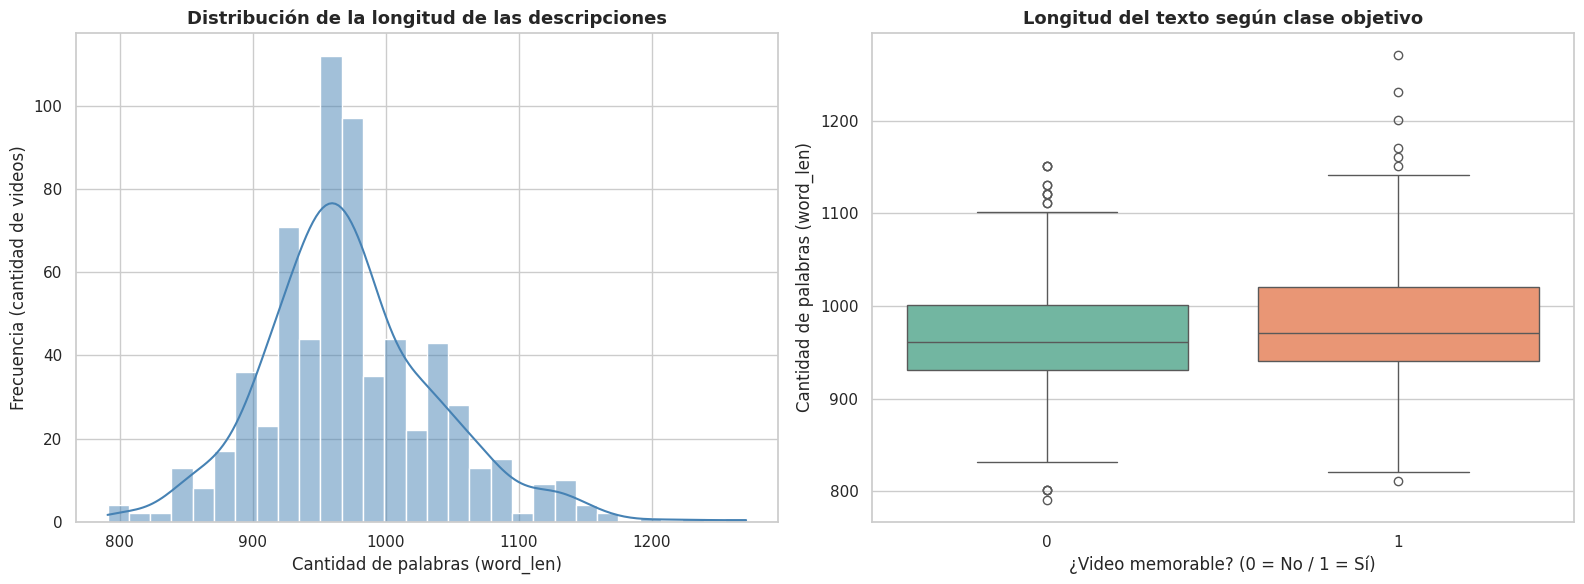


3) TOP 20 PALABRAS MÁS FRECUENTES DEL CORPUS CRUDO
Tokens totales : 641,359
Vocabulario    : 739 términos únicos

[('a', 153774), ('in', 47570), ('of', 29680), ('is', 26810), ('man', 25101), ('holding', 18500), ('woman', 18255), ('cell', 17930), ('standing', 17460), ('and', 14440), ('on', 13400), ('phone', 11090), ('hand.', 11080), ('with', 10490), ('front', 8790), ('the', 8740), ('person', 8441), ('sitting', 8250), ('her', 7150), ('suit', 7103)]

Detalle ordenado:
 1. a             153,774  (23.98% del corpus)
 2. in             47,570  (7.42% del corpus)
 3. of             29,680  (4.63% del corpus)
 4. is             26,810  (4.18% del corpus)
 5. man            25,101  (3.91% del corpus)
 6. holding        18,500  (2.88% del corpus)
 7. woman          18,255  (2.85% del corpus)
 8. cell           17,930  (2.80% del corpus)
 9. standing       17,460  (2.72% del corpus)
10. and            14,440  (2.25% del corpus)
11. on             13,400  (2.09% del corpus)
12. phone          11,

In [14]:
# =============================================================================
# BLOQUE 2: ANÁLISIS EXPLORATORIO DE DATOS (EDA) DE TEXTO
# =============================================================================
# Objetivo: caracterizar el corpus de descripciones ('cc') antes de normalizarlo.
# Buscamos responder tres preguntas que condicionan el diseño del Bloque 3:
#   (a) ¿Cuál es la extensión típica de una descripción?
#   (b) ¿La longitud del texto discrimina por sí sola entre videos memorables
#       y no memorables? (sería una feature "gratis" para el modelo)
#   (c) ¿Qué vocabulario domina el corpus crudo?
# Trabaja sobre 'df_unificado', ya disponible en memoria desde el Bloque 1.
# =============================================================================

# -----------------------------------------------------------------------------
# 0. Importación de librerías
# -----------------------------------------------------------------------------
from collections import Counter

import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------------------------------------------------------
# 1. FEATURES TEMPORALES DE LONGITUD Y ESTADÍSTICA DESCRIPTIVA
# -----------------------------------------------------------------------------
# Se crean dos métricas de extensión, marcadas como TEMPORALES: sirven para el
# diagnóstico exploratorio de este bloque y se eliminan al final (paso 5) para
# no contaminar el DataFrame que alimentará al modelo.
#   - 'char_len': cantidad de caracteres (incluye espacios y puntuación).
#   - 'word_len': cantidad de tokens separando por espacios simples. Es un conteo
#     deliberadamente ingenuo (no es tokenización lingüística): en esta etapa nos
#     interesa dimensionar el texto crudo, tal como viene del archivo fuente.
df_unificado['char_len'] = df_unificado['cc'].str.len()
df_unificado['word_len'] = df_unificado['cc'].str.split(' ').str.len()

print("=" * 70)
print("1) ESTADÍSTICA DESCRIPTIVA DE LA LONGITUD DE LAS DESCRIPCIONES")
print("=" * 70)
print(df_unificado[['char_len', 'word_len']].describe())

# -----------------------------------------------------------------------------
# 2. VISUALIZACIÓN DUAL: DISTRIBUCIÓN Y PODER DISCRIMINANTE DE LA LONGITUD
# -----------------------------------------------------------------------------
# Panel izquierdo  -> ¿cómo se distribuye la longitud en el corpus? (forma,
#                     asimetría, presencia de colas largas o multimodalidad)
# Panel derecho    -> ¿esa longitud separa las clases? Si ambas cajas se solapan
#                     casi por completo, la longitud NO es informativa por sí
#                     sola y el poder predictivo deberá venir del contenido
#                     semántico del texto, no de su extensión.
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 2.a) Izquierda: histograma + estimación de densidad por kernel (KDE).
sns.histplot(data=df_unificado, x='word_len', kde=True, bins=30,
             color='steelblue', ax=axes[0])
axes[0].set_title('Distribución de la longitud de las descripciones',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Cantidad de palabras (word_len)')
axes[0].set_ylabel('Frecuencia (cantidad de videos)')

# 2.b) Derecha: boxplot de la longitud segmentado por la variable objetivo.
sns.boxplot(data=df_unificado, x='memorable', y='word_len',
            hue='memorable', palette='Set2', legend=False, ax=axes[1])
axes[1].set_title('Longitud del texto según clase objetivo',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('¿Video memorable? (0 = No / 1 = Sí)')
axes[1].set_ylabel('Cantidad de palabras (word_len)')

plt.tight_layout()
plt.show()

# -----------------------------------------------------------------------------
# 3. FRECUENCIA DE TÉRMINOS EN EL CORPUS CRUDO
# -----------------------------------------------------------------------------
# Se concatena todo el corpus en un único string, se pasa a minúsculas para que
# 'The' y 'the' no se cuenten como términos distintos, y se tokeniza por espacios.
# Counter.most_common(20) devuelve los 20 términos más frecuentes.
corpus_crudo = ' '.join(df_unificado['cc'].astype(str)).lower()
frecuencia_palabras = Counter(corpus_crudo.split())
top_20_palabras = frecuencia_palabras.most_common(20)

print("\n" + "=" * 70)
print("3) TOP 20 PALABRAS MÁS FRECUENTES DEL CORPUS CRUDO")
print("=" * 70)
print(f"Tokens totales : {sum(frecuencia_palabras.values()):,}")
print(f"Vocabulario    : {len(frecuencia_palabras):,} términos únicos\n")

print(top_20_palabras)

print("\nDetalle ordenado:")
total_tokens = sum(frecuencia_palabras.values())
for posicion, (palabra, conteo) in enumerate(top_20_palabras, start=1):
    print(f"{posicion:>2}. {palabra:<12} {conteo:>8,}  ({conteo / total_tokens:.2%} del corpus)")

# -----------------------------------------------------------------------------
# 4. ANÁLISIS: POR QUÉ ES NECESARIO NORMALIZAR (JUSTIFICACIÓN DEL BLOQUE 3)
# -----------------------------------------------------------------------------
# El ranking está dominado casi por completo por STOPWORDS o términos vacíos
# ("a", "the", "in", "and", "of", "on"): son palabras funcionales que sostienen
# la sintaxis del inglés pero no aportan contenido semántico discriminante.
# Aparecen con altísima frecuencia en TODOS los documentos, tanto en los videos
# memorables como en los no memorables, por lo que su poder para separar clases
# es prácticamente nulo.
#
# Consecuencias concretas si vectorizáramos el texto sin normalizar:
#   - DOMINIO DE LA REPRESENTACIÓN: en un Bag-of-Words o en un TF-IDF sin ajuste,
#     estos términos concentran la mayor parte de la masa de conteos y opacan a
#     las palabras de contenido ("man", "woman", "dog", "building"), que son las
#     que realmente describen la escena del video.
#   - RUIDO Y DIMENSIONALIDAD: se infla el vocabulario con tokens inútiles,
#     encareciendo el entrenamiento y aumentando el riesgo de sobreajuste.
#   - DISTORSIÓN DE LA SIMILITUD: dos descripciones de escenas completamente
#     distintas parecerían similares solo por compartir artículos y preposiciones.
#
# Por eso el Bloque 3 aplicará un pipeline de normalización: pasaje a minúsculas,
# eliminación de puntuación y de stopwords, y lematización, de modo que el
# vectorizador reciba únicamente los términos con carga semántica real.
#
# HALLAZGO ADICIONAL DEL EDA (a contemplar en el Bloque 3):
# cada caption viene con su texto base REPETIDO 10 VECES de forma consecutiva.
# Esto es un artefacto del archivo fuente, no información genuina: infla por diez
# tanto 'char_len'/'word_len' como todos los conteos de frecuencia, sin agregar
# una sola palabra nueva. No altera el ranking relativo del top 20 (todo escala
# por el mismo factor), pero sí exige deduplicar el texto antes de vectorizar
# para no sesgar los pesos de TF-IDF. Lo verificamos explícitamente:
def factor_de_repeticion(texto):
    """Devuelve cuántas veces el texto es la repetición exacta de su unidad mínima."""
    n = len(texto)
    for k in range(1, n // 2 + 1):
        if n % k == 0 and texto[:k] * (n // k) == texto:
            return n // k
    return 1


factores = df_unificado['cc'].head(30).apply(factor_de_repeticion)

print("\n" + "=" * 70)
print("4) VERIFICACIÓN DEL ARTEFACTO DE REPETICIÓN")
print("=" * 70)
factor_dominante = int(factores.mode()[0])
print(f"Factores de repetición hallados (muestra de 30 captions): {sorted(int(f) for f in factores.unique())}")
print(f"Longitud media observada    : {df_unificado['word_len'].mean():,.1f} palabras")
print(f"Longitud real (deduplicada) : {df_unificado['word_len'].mean() / factor_dominante:,.1f} palabras aprox.")
print(f">> El texto útil es ~{factor_dominante} veces menor que el que reportan las métricas crudas.")

# -----------------------------------------------------------------------------
# 5. LIMPIEZA: ELIMINACIÓN DE LAS COLUMNAS TEMPORALES
# -----------------------------------------------------------------------------
# Las métricas de longitud cumplieron su función diagnóstica. Se descartan para
# que 'df_unificado' vuelva a contener exclusivamente los datos originales del
# desafío y el Bloque 3 parta de un estado limpio y predecible.
df_unificado = df_unificado.drop(columns=['char_len', 'word_len'])

print("\n" + "=" * 70)
print("5) LIMPIEZA DE COLUMNAS TEMPORALES")
print("=" * 70)
print(f"Columnas eliminadas: ['char_len', 'word_len']")
print(f"Columnas restantes en df_unificado: {list(df_unificado.columns)}")
print(f"Shape final: {df_unificado.shape[0]} filas x {df_unificado.shape[1]} columnas")

print("\n" + "=" * 70)
print("BLOQUE 2 FINALIZADO: corpus caracterizado, listo para normalizar.")
print("=" * 70)

### Bloque 3: Pipeline de Normalización, Limpieza y Canonización de Texto

Transformamos las descripciones crudas en texto canónico apto para vectorizar, atacando los dos problemas que dejó el EDA: la repetición 10x del contenido y el dominio de stopwords y puntuación adherida. El resultado se guarda en `cc_clean`, preservando `cc` intacta para poder auditar el antes y el después.

In [15]:
# =============================================================================
# BLOQUE 3: PIPELINE DE NORMALIZACIÓN, LIMPIEZA Y CANONIZACIÓN DE TEXTO
# =============================================================================
# Objetivo: transformar las descripciones crudas ('cc') en texto canónico apto
# para vectorizar. El Bloque 2 dejó dos diagnósticos que este pipeline resuelve:
#   (1) cada caption trae su contenido repetido 10 veces (artefacto del origen);
#   (2) el corpus está dominado por stopwords ("a" concentraba el 24% de los
#       tokens) y arrastra puntuación adherida a las palabras ("hand.").
# El resultado se guarda en una columna nueva 'cc_clean', preservando 'cc'
# intacta para poder auditar el antes y el después.
# =============================================================================

# -----------------------------------------------------------------------------
# 1. DEPENDENCIAS Y RECURSOS LINGÜÍSTICOS
# -----------------------------------------------------------------------------
import re

import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

# Corpus auxiliares de NLTK. 'stopwords' aporta la lista de términos vacíos del
# inglés; 'wordnet' es la base léxica que requeriría el WordNetLemmatizer, y se
# descarga para dejar disponible la alternativa de lematización.
nltk.download('stopwords')
nltk.download('wordnet')

# Se instancian UNA SOLA VEZ, fuera de las funciones de limpieza. Construir el
# set de stopwords o el stemmer en cada llamada implicaría rehacer ese trabajo
# 659 veces sin ninguna necesidad.
# El set (no lista) es deliberado: la pertenencia `token in STOP_WORDS` es O(1)
# en un set y O(n) en una lista; con ~641k tokens la diferencia es sustancial.
STOP_WORDS = set(stopwords.words('english'))
stemmer = PorterStemmer()


# -----------------------------------------------------------------------------
# 2. FUNCIONES DEL PIPELINE
# -----------------------------------------------------------------------------
# El corpus presenta un artefacto de origen que condiciona el diseño: las 10
# repeticiones de cada caption vienen concatenadas SIN separador entre sí, de
# modo que la última oración de una repetición queda soldada a la primera de la
# siguiente ("...in their hand" + "a man in a suit..." -> "...in their handa
# man in a suit..."). Esa unión NO contiene '. ', por lo que sobrevive a una
# deduplicación basada en separar por punto y espacio.
#
# Por eso se implementan dos estrategias de deduplicación que comparten la misma
# normalización lingüística posterior:
#   - clean_caption()             -> separa por '. ' (deja la sutura sin cortar).
#   - clean_caption_sin_sutura()  -> recorta primero la unidad repetida, con lo
#                                    cual la sutura desaparece de raíz.
# La segunda es la que se aplica al corpus; la primera se conserva como control
# para poder cuantificar la mejora en el diagnóstico del paso 4.

def unidad_base(texto):
    """Devuelve la unidad mínima cuya repetición reconstruye el texto completo.

    Recorre las longitudes candidatas 'k' que dividen exactamente al texto y
    devuelve el primer prefijo cuya repetición lo reproduce. Si el texto no es
    periódico, devuelve el texto sin modificar.
    """
    n = len(texto)
    for k in range(1, n // 2 + 1):
        if n % k == 0 and texto[:k] * (n // k) == texto:
            return texto[:k]
    return texto


def normalizar_tokens(texto):
    """Aplica la normalización lingüística común a ambas estrategias.

    Corresponde a los pasos b, c, d y e del pipeline:
        b. Minúsculas y eliminación de caracteres no alfanuméricos.
        c. Tokenización por espacios y remoción de stopwords del inglés.
        d. Reducción morfológica mediante stemming de Porter.
        e. Reensamblado en una cadena separada por espacios simples.
    """
    # b. Minúsculas primero, para que 'The' y 'the' colapsen en un único término.
    #    Luego se descarta todo lo que no sea alfanumérico o espacio: así se
    #    despega la puntuación que en el Bloque 2 generaba tokens espurios como
    #    'hand.' contabilizados aparte de 'hand'.
    texto = texto.lower()
    texto = re.sub(r'[^a-zA-Z0-9\s]', '', texto)

    # c. Se descartan los términos vacíos: palabras funcionales que aparecen en
    #    todos los documentos por igual y no aportan capacidad discriminante.
    tokens = [token for token in texto.split() if token not in STOP_WORDS]

    # d. El stemmer de Porter recorta las flexiones hasta la raíz, de modo que
    #    variantes como 'holding'/'holds'/'held' converjan a un mismo morfema.
    tokens = [stemmer.stem(token) for token in tokens]

    # e. Reensamblado.
    return ' '.join(tokens)


def clean_caption(text):
    """Normaliza deduplicando oraciones al separar por '. ' (versión de control).

    Deja sin cortar la sutura entre repeticiones, por lo que introduce términos
    espurios en el vocabulario. Se conserva únicamente como referencia para
    dimensionar la mejora de la variante correctiva.
    """
    # a. Deduplicación de oraciones preservando el orden de aparición.
    #    dict.fromkeys() es la forma idiomática de deduplicar manteniendo el
    #    orden: los diccionarios de Python garantizan el orden de inserción y,
    #    como las claves no se repiten, la deduplicación es automática.
    oraciones_unicas = list(dict.fromkeys(text.split('. ')))
    return normalizar_tokens('. '.join(oraciones_unicas))


def clean_caption_sin_sutura(text):
    """Normaliza recortando primero la unidad repetida (versión aplicada).

    Al quedarse con la unidad base ANTES de separar en oraciones, la sutura
    entre repeticiones desaparece de raíz y no llega a generar términos
    inexistentes como 'handa' o 'buildinga'.
    """
    # a. Se recorta la unidad repetida y recién entonces se deduplican las
    #    oraciones que la propia unidad pudiera repetir internamente.
    oraciones_unicas = list(dict.fromkeys(unidad_base(text).split('. ')))
    return normalizar_tokens('. '.join(oraciones_unicas))


# -----------------------------------------------------------------------------
# 3. APLICACIÓN DEL PIPELINE AL CORPUS
# -----------------------------------------------------------------------------
# Se escribe en una columna NUEVA ('cc_clean') en lugar de sobrescribir 'cc':
# conservar el original permite auditar el resultado y reprocesar el corpus con
# otros criterios sin tener que volver a leer los archivos fuente.
# Se utiliza la variante correctiva, que elimina las uniones defectuosas.
df_unificado['cc_clean'] = df_unificado['cc'].apply(clean_caption_sin_sutura)

# -----------------------------------------------------------------------------
# 4. PRESENTACIÓN DE RESULTADOS Y DIAGNÓSTICO DEL PIPELINE
# -----------------------------------------------------------------------------

# --- 4.a) Comparación cualitativa: antes y después -------------------------
print("=" * 78)
print("4.a) COMPARACIÓN ANTES / DESPUÉS DE LA NORMALIZACIÓN")
print("=" * 78)

for posicion in [0, 1]:
    fila = df_unificado.iloc[posicion]
    print(f"\n--- MUESTRA {posicion + 1}  |  sequence_name: {fila['sequence_name']} ---")
    print(f"    (memorable = {fila['memorable']}  |  score = {fila['memorability_score']:.3f})")

    print(f"\n  [ORIGINAL - 'cc']  ({len(fila['cc'].split())} palabras, {len(fila['cc'])} caracteres)")
    print(f"  {fila['cc'][:300]}...")

    print(f"\n  [NORMALIZADO - 'cc_clean']  ({len(fila['cc_clean'].split())} palabras, {len(fila['cc_clean'])} caracteres)")
    print(f"  {fila['cc_clean']}")
    print("-" * 78)

# --- 4.b) Estadística descriptiva de la longitud resultante ----------------
# Se mide la extensión del texto ya canonizado para dimensionar cuánto ruido
# eliminó el pipeline respecto de las ~973 palabras crudas del Bloque 2.
longitud_limpia = df_unificado['cc_clean'].str.split().str.len()

print("\n" + "=" * 78)
print("4.b) ESTADÍSTICA DESCRIPTIVA DE LA LONGITUD DE 'cc_clean'")
print("=" * 78)
print(longitud_limpia.describe())

LONGITUD_CRUDA_MEDIA = 973.2  # media observada en el Bloque 2 (texto sin limpiar)
media_limpia = longitud_limpia.mean()

print(f"\nMedia de longitud observada : {media_limpia:.2f} palabras por descripción")
print(f"Media original (Bloque 2)   : {LONGITUD_CRUDA_MEDIA:.2f} palabras por descripción")
print(f"Reducción de longitud       : {1 - media_limpia / LONGITUD_CRUDA_MEDIA:.2%}")

# --- 4.c) Reducción del vocabulario ----------------------------------------
# El vocabulario es el conjunto de términos únicos del corpus y determina
# directamente la dimensionalidad de la matriz que recibirá el modelo.
VOCABULARIO_CRUDO = 739  # términos únicos medidos en el Bloque 2

vocabulario_limpio = set()
for texto in df_unificado['cc_clean']:
    vocabulario_limpio.update(texto.split())

print("\n" + "=" * 78)
print("4.c) REDUCCIÓN DEL VOCABULARIO")
print("=" * 78)
print(f"Vocabulario original (Bloque 2) : {VOCABULARIO_CRUDO:,} términos únicos")
print(f"Vocabulario normalizado         : {len(vocabulario_limpio):,} términos únicos")
print(f"Reducción del vocabulario       : {1 - len(vocabulario_limpio) / VOCABULARIO_CRUDO:.2%}")
print(f"Tokens totales tras la limpieza : {int(longitud_limpia.sum()):,}")

# --- 4.d) Verificación del corte de sutura ---------------------------------
# Se contrasta contra la variante de control para dejar documentado cuánto ruido
# habría quedado en el vocabulario de no haber cortado la unión entre
# repeticiones. Los términos que sólo existen en la variante de control son, por
# construcción, artefactos de concatenación.
control = df_unificado['cc'].apply(clean_caption)
vocabulario_control = set()
for texto in control:
    vocabulario_control.update(texto.split())

terminos_espurios = sorted(vocabulario_control - vocabulario_limpio)
captions_periodicos = (df_unificado['cc'].apply(lambda t: len(unidad_base(t)) < len(t))).sum()

print("\n" + "=" * 78)
print("4.d) VERIFICACIÓN DEL CORTE DE SUTURA")
print("=" * 78)
print(f"Captions con repetición detectada : {captions_periodicos} de {len(df_unificado)} "
      f"({captions_periodicos / len(df_unificado):.1%})")
print(f"Términos espurios evitados        : {len(terminos_espurios)} "
      f"({len(terminos_espurios) / len(vocabulario_control):.1%} del vocabulario de control)")
print(f"Ejemplos de lo que se evitó       : {terminos_espurios[:12]}")
print(f"\nComparación de estrategias de deduplicación:")
print(f"{'':<24}{'por . ':>12}{'sin sutura':>14}")
print(f"{'media de palabras':<24}{control.str.split().str.len().mean():>12.2f}{media_limpia:>14.2f}")
print(f"{'vocabulario':<24}{len(vocabulario_control):>12}{len(vocabulario_limpio):>14}")
print(f"{'reducción vs 739':<24}{1 - len(vocabulario_control) / VOCABULARIO_CRUDO:>11.1%}"
      f"{1 - len(vocabulario_limpio) / VOCABULARIO_CRUDO:>14.1%}")
print("\n>> 'cc_clean' se genera con la variante sin sutura: vocabulario depurado,")
print(">> sin términos inexistentes producto de la concatenación.")

print("\n" + "=" * 78)
print("BLOQUE 3 FINALIZADO: columna 'cc_clean' lista para la vectorización.")
print("=" * 78)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


4.a) COMPARACIÓN ANTES / DESPUÉS DE LA NORMALIZACIÓN

--- MUESTRA 1  |  sequence_name: 127_hours_2000_2010_1 ---
    (memorable = 1  |  score = 1.000)

  [ORIGINAL - 'cc']  (1051 palabras, 4450 caracteres)
  a man in a suit and tie standing in front of a building. a man holding a cat in his hand. a black and white photo of a cat and a cat. a man in a suit and tie standing in front of a building. a close up of a black and white photo of a bird. a man laying on a bed with a cat. a close up of a person hol...

  [NORMALIZADO - 'cc_clean']  (44 palabras, 221 caracteres)
  man suit tie stand front build man hold cat hand black white photo cat cat close black white photo bird man lay bed cat close person hold cell phone man suit tie hold cell phone man lay bed dog person hold cell phone hand
------------------------------------------------------------------------------

--- MUESTRA 2  |  sequence_name: 127_hours_2182_2192_5 ---
    (memorable = 0  |  score = 0.000)

  [ORIGINAL - 'cc']  (971

### Bloque 4: Modelo Baseline (TF-IDF + Clasificador Lineal)

Establecemos un punto de referencia cuantitativo contra el cual medir cualquier modelo posterior: representación dispersa del texto con TF-IDF y un clasificador lineal (regresión logística). Si un modelo más complejo no supera este baseline, esa complejidad no está justificada.

A) DIVISIÓN DE DATOS
Total de observaciones : 659
Set de entrenamiento   : 441 (66.9%)
Set de prueba          : 218 (33.1%)

Verificación de la estratificación (proporción de clase 1 'memorable'):
  Set completo    : 44.01%
  Entrenamiento   : 43.99%
  Prueba          : 44.04%

B) VECTORIZACIÓN TF-IDF
Vocabulario aprendido del set de entrenamiento : 327 términos
Matriz de entrenamiento : 441 documentos x 327 features
Matriz de prueba        : 218 documentos x 327 features
Densidad de la matriz   : 5.43% de celdas no nulas (representación dispersa)

C) ENTRENAMIENTO DEL MODELO
Modelo   : LogisticRegression
Features : 327
Clases   : [0 1]
Convergencia alcanzada en 10 iteraciones (límite: 10000).

D) EVALUACIÓN SOBRE EL SET DE PRUEBA
                  precision    recall  f1-score   support

No memorable (0)      0.605     0.730     0.662       122
   Memorable (1)      0.535     0.396     0.455        96

        accuracy                          0.583       218
       macro avg      0.5

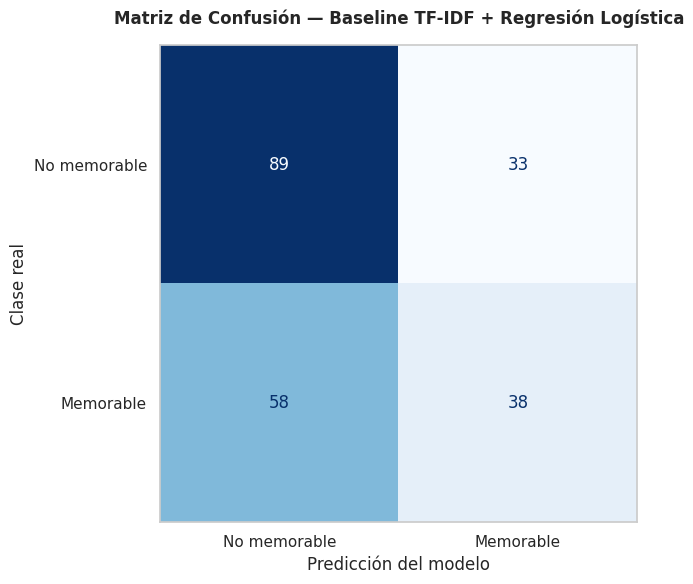


BLOQUE 4 FINALIZADO: baseline establecido como punto de comparación.


In [16]:
# =============================================================================
# BLOQUE 4: MODELO BASELINE (TF-IDF + CLASIFICADOR LINEAL)
# =============================================================================
# Objetivo: establecer un punto de referencia cuantitativo contra el cual medir
# cualquier modelo posterior. La lógica del diseño es deliberadamente clásica:
# representación dispersa del texto (TF-IDF) + clasificador lineal (regresión
# logística). Si un modelo más complejo no supera este baseline, esa complejidad
# no está justificada.
# Trabaja sobre 'df_unificado', con la columna 'cc_clean' generada en el Bloque 3.
# =============================================================================

# -----------------------------------------------------------------------------
# 0. Importación de librerías
# -----------------------------------------------------------------------------
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, classification_report
from sklearn.model_selection import train_test_split

# -----------------------------------------------------------------------------
# A. DIVISIÓN DE DATOS (TRAIN / TEST SPLIT)
# -----------------------------------------------------------------------------
# X : variable independiente, el texto ya canonizado en el Bloque 3.
# y : variable objetivo, la etiqueta binaria de memorabilidad.
X = df_unificado['cc_clean']
y = df_unificado['memorable']

# Decisiones del diseño estadístico:
#   - test_size=0.33  -> reserva un tercio de los datos para una evaluación
#     honesta. Con sólo 659 observaciones hay una tensión real: un test chico
#     da métricas inestables, uno grande deja poco para entrenar. Un tercio
#     (~218 casos) es el compromiso usado en los ejemplos de la materia.
#   - random_state=42 -> fija la semilla del muestreo. Sin esto, cada ejecución
#     produciría una partición distinta y las métricas no serían reproducibles.
#   - stratify=y      -> CLAVE. Fuerza a que la proporción de clases del set
#     completo (44% memorable, medido en el Bloque 1) se respete tanto en train
#     como en test. Sin estratificar, el azar podría dejar un test con una
#     composición de clases muy distinta a la real y las métricas medirían esa
#     distorsión en lugar del desempeño del modelo.
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.33,
    random_state=42,
    stratify=y
)

print("=" * 78)
print("A) DIVISIÓN DE DATOS")
print("=" * 78)
print(f"Total de observaciones : {len(X)}")
print(f"Set de entrenamiento   : {len(X_train)} ({len(X_train) / len(X):.1%})")
print(f"Set de prueba          : {len(X_test)} ({len(X_test) / len(X):.1%})")
print("\nVerificación de la estratificación (proporción de clase 1 'memorable'):")
print(f"  Set completo    : {y.mean():.2%}")
print(f"  Entrenamiento   : {y_train.mean():.2%}")
print(f"  Prueba          : {y_test.mean():.2%}")

# -----------------------------------------------------------------------------
# B. VECTORIZACIÓN TF-IDF
# -----------------------------------------------------------------------------
# TF-IDF convierte cada descripción en un vector numérico donde cada dimensión
# es un término del vocabulario. El peso combina dos señales:
#   - TF  (term frequency)          : cuánto aparece el término en ESE documento.
#   - IDF (inverse document frequency): cuán raro es el término en el CORPUS.
# Un término frecuente en un documento pero raro en el corpus recibe peso alto,
# porque es justamente lo que distingue a ese documento de los demás.
#
# Parámetros de la configuración estándar de la materia:
#   - use_idf=True      -> activa la ponderación IDF. Sin esto sería un simple
#                          conteo y los términos ubicuos dominarían.
#   - sublinear_tf=True -> aplica 1 + log(tf) en lugar de tf. Amortigua el efecto
#                          de las repeticiones: que un término aparezca 10 veces
#                          no lo hace 10 veces más relevante que si apareciera 1.
#   - norm='l2'         -> normaliza cada vector a longitud unitaria, de modo que
#                          las descripciones largas no pesen más que las cortas
#                          por el solo hecho de tener más términos.
vectorizer = TfidfVectorizer(use_idf=True, sublinear_tf=True, norm='l2')

# DISCIPLINA METODOLÓGICA: fit_transform SÓLO sobre train, transform sobre test.
# El vectorizador aprende el vocabulario y los pesos IDF exclusivamente del set
# de entrenamiento. Si se ajustara sobre el total, la estadística del test se
# filtraría al modelo (data leakage) y la evaluación quedaría contaminada.
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("\n" + "=" * 78)
print("B) VECTORIZACIÓN TF-IDF")
print("=" * 78)
print(f"Vocabulario aprendido del set de entrenamiento : {len(vectorizer.vocabulary_):,} términos")
print(f"Matriz de entrenamiento : {X_train_tfidf.shape[0]} documentos x {X_train_tfidf.shape[1]} features")
print(f"Matriz de prueba        : {X_test_tfidf.shape[0]} documentos x {X_test_tfidf.shape[1]} features")
densidad = X_train_tfidf.nnz / (X_train_tfidf.shape[0] * X_train_tfidf.shape[1])
print(f"Densidad de la matriz   : {densidad:.2%} de celdas no nulas (representación dispersa)")

# -----------------------------------------------------------------------------
# C. ENTRENAMIENTO DEL MODELO BASELINE
# -----------------------------------------------------------------------------
# La regresión logística es la elección natural como baseline de texto: es lineal
# sobre un espacio de alta dimensión (donde los datos suelen ser separables),
# entrena rápido y sus coeficientes son interpretables término a término.
#   - max_iter=10000  -> holgura para que el solver converja. El default (100)
#                        suele quedarse corto en matrices dispersas y emite un
#                        ConvergenceWarning.
#   - random_state=42 -> reproducibilidad del ajuste.
modelo = LogisticRegression(max_iter=10000, random_state=42)
modelo.fit(X_train_tfidf, y_train)

print("\n" + "=" * 78)
print("C) ENTRENAMIENTO DEL MODELO")
print("=" * 78)
print(f"Modelo   : {modelo.__class__.__name__}")
print(f"Features : {modelo.n_features_in_:,}")
print(f"Clases   : {modelo.classes_}")
print(f"Convergencia alcanzada en {modelo.n_iter_[0]} iteraciones (límite: {modelo.max_iter}).")

# -----------------------------------------------------------------------------
# D. EVALUACIÓN DE PERFORMANCE
# -----------------------------------------------------------------------------
# Se predice sobre el set de prueba, que el modelo no vio en ningún momento.
y_pred = modelo.predict(X_test_tfidf)

# REFERENCIA OBLIGADA: el clasificador trivial que siempre predice la clase
# mayoritaria. En un problema desbalanceado el accuracy puede parecer alto sin
# que el modelo haya aprendido nada; comparar contra este piso es lo que permite
# interpretar la métrica correctamente.
accuracy_mayoritaria = max(y_test.mean(), 1 - y_test.mean())

print("\n" + "=" * 78)
print("D) EVALUACIÓN SOBRE EL SET DE PRUEBA")
print("=" * 78)
print(classification_report(
    y_test, y_pred,
    target_names=['No memorable (0)', 'Memorable (1)'],
    digits=3
))

print(f"Piso de referencia (predecir siempre la clase mayoritaria): {accuracy_mayoritaria:.2%}")
print("Cómo leer el reporte:")
print("  - precision : de lo que el modelo marcó como de una clase, cuánto acertó.")
print("  - recall    : de los casos reales de esa clase, cuántos logró recuperar.")
print("  - f1-score  : media armónica de ambas; penaliza los desempeños asimétricos.")
print("  - support   : cantidad de casos reales de cada clase en el set de prueba.")

# --- Matriz de confusión ---------------------------------------------------
# Desagrega el accuracy en los cuatro cuadrantes y muestra el TIPO de error:
# la diagonal son los aciertos, y fuera de ella se ve si el modelo tiende a
# sobre-predecir una clase en particular.
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay.from_estimator(
    modelo,
    X_test_tfidf,
    y_test,
    display_labels=['No memorable', 'Memorable'],
    cmap='Blues',
    colorbar=False,
    values_format='d',
    ax=ax
)
ax.set_title('Matriz de Confusión — Baseline TF-IDF + Regresión Logística',
             fontsize=12, fontweight='bold', pad=15)
ax.set_xlabel('Predicción del modelo')
ax.set_ylabel('Clase real')
ax.grid(False)
plt.tight_layout()
plt.show()

print("\n" + "=" * 78)
print("BLOQUE 4 FINALIZADO: baseline establecido como punto de comparación.")
print("=" * 78)

### Bloque 5a: Modelo Avanzado — Red Secuencial (LSTM + Learned Embeddings)

El baseline trata cada descripción como una bolsa de palabras y pierde el orden de los términos. Acá introducimos la primera arquitectura que sí modela la secuencia: una capa `Embedding` que aprende una representación densa de cada término durante el entrenamiento, y una `LSTM` que recorre la secuencia manteniendo un estado interno.

In [17]:
# =============================================================================
# BLOQUE 5a: MODELO AVANZADO — RED SECUENCIAL (LSTM + LEARNED EMBEDDINGS)
# =============================================================================
# El baseline del Bloque 4 (TF-IDF + regresión logística) trata cada descripción
# como una bolsa de palabras: pierde por completo el ORDEN de los términos.
# Este bloque introduce la primera arquitectura que sí modela la secuencia:
#   - una capa Embedding que aprende una representación densa de cada término
#     durante el entrenamiento (a diferencia de TF-IDF, que es una estadística
#     fija calculada de antemano);
#   - una capa LSTM que recorre la secuencia manteniendo un estado interno, con
#     lo cual la posición y el contexto de cada palabra influyen en la salida.
# Reutiliza el split estratificado (X_train, X_test, y_train, y_test) del Bloque 4.
# =============================================================================

# -----------------------------------------------------------------------------
# 0. Importación de librerías
# -----------------------------------------------------------------------------
import numpy as np
import keras
from keras.models import Sequential
from keras.layers import Dense, Embedding, LSTM, SpatialDropout1D
from keras.preprocessing.sequence import pad_sequences
from sklearn.metrics import classification_report

# NOTA DE COMPATIBILIDAD: en Keras 3 el módulo 'keras.preprocessing.text' ya no
# existe como tal; la clase Tokenizer sigue disponible a través del espacio de
# nombres de TensorFlow. Se importa desde allí para que la celda corra tanto en
# Keras 2 como en Keras 3 (la versión que hoy trae Colab).
from tensorflow.keras.preprocessing.text import Tokenizer

# Semilla global: fija la inicialización de pesos y el barajado de los batches.
# Sin esto, dos ejecuciones del mismo código darían métricas distintas.
keras.utils.set_random_seed(42)

# -----------------------------------------------------------------------------
# 1. TOKENIZACIÓN E INDEXACIÓN
# -----------------------------------------------------------------------------
# El Tokenizer construye un diccionario término -> entero. La red no consume
# texto: consume índices que luego la capa Embedding traduce a vectores densos.
#
# Tamaño del vocabulario: se toma el conteo real de términos únicos que dejó el
# pipeline del Bloque 3 sobre 'cc_clean' (356 tras el corte de sutura).
VOCAB_SIZE = len(set(' '.join(df_unificado['cc_clean']).split()))

# oov_token reserva un índice para los términos que aparezcan en test pero no en
# train. Sin él, esas palabras se descartarían en silencio y las secuencias de
# prueba quedarían mutiladas sin dejar rastro.
tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')

# DISCIPLINA METODOLÓGICA: el índice se aprende SÓLO del set de entrenamiento,
# igual que se hizo con el TF-IDF en el Bloque 4. Ajustarlo sobre el corpus
# completo filtraría información del set de prueba al modelo (data leakage).
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

print("=" * 78)
print("1) TOKENIZACIÓN E INDEXACIÓN")
print("=" * 78)
print(f"Tamaño de vocabulario configurado : {VOCAB_SIZE} términos")
print(f"Términos indexados desde train    : {len(tokenizer.word_index)}")
print(f"Ejemplo de secuencia (primeros 15 índices): {X_train_seq[0][:15]}")

# -----------------------------------------------------------------------------
# 2. PADDING (ESTANDARIZACIÓN DEL LARGO DE LAS SECUENCIAS)
# -----------------------------------------------------------------------------
# Una capa LSTM procesa tensores rectangulares: todas las secuencias del batch
# deben tener el mismo largo. Como las descripciones varían (entre 5 y 55
# palabras tras la limpieza), se rellenan con ceros hasta 'MAXLEN'.
#   - maxlen=55       -> el máximo real observado en el Bloque 3. Elegirlo así
#                        evita truncar información: ninguna descripción se corta.
#   - padding='post'  -> los ceros van AL FINAL. Es la convención natural cuando
#                        se usa mask_zero: el contenido real queda al principio.
MAXLEN = 55

X_train_pad = pad_sequences(X_train_seq, maxlen=MAXLEN, padding='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=MAXLEN, padding='post')

# Keras espera arrays de NumPy; y_train/y_test son Series de pandas.
y_train_np = y_train.values
y_test_np = y_test.values

print("\n" + "=" * 78)
print("2) PADDING DE SECUENCIAS")
print("=" * 78)
print(f"Longitud fijada (maxlen) : {MAXLEN}")
print(f"X_train_pad : {X_train_pad.shape}   X_test_pad : {X_test_pad.shape}")

# -----------------------------------------------------------------------------
# 3. ARQUITECTURA DEL MODELO
# -----------------------------------------------------------------------------
# Embedding        : mapea cada índice a un vector denso de 100 dimensiones que
#                    se APRENDE durante el entrenamiento. input_dim lleva un +1
#                    porque el índice 0 está reservado para el padding.
#                    mask_zero=True indica a las capas siguientes que ignoren esas
#                    posiciones de relleno: sin esto, la LSTM procesaría decenas
#                    de ceros como si fueran contenido real.
# SpatialDropout1D : apaga el 100*0.2 % de las DIMENSIONES completas del embedding
#                    (no neuronas sueltas). Es la variante correcta para texto:
#                    fuerza a la red a no depender de una única dimensión latente.
# LSTM(64)         : recorre la secuencia con 64 unidades de memoria. Sus compuertas
#                    deciden qué información conservar y cuál descartar, lo que le
#                    permite capturar dependencias entre términos distantes.
# Dense(1, sigmoid): una única neurona con salida en [0,1], interpretable como la
#                    probabilidad de que el video sea memorable.
EMBEDDING_DIM = 100

modelo_lstm = Sequential([
    Embedding(input_dim=VOCAB_SIZE + 1,
              output_dim=EMBEDDING_DIM,
              input_length=MAXLEN,
              mask_zero=True),
    SpatialDropout1D(0.2),
    LSTM(64),
    Dense(1, activation='sigmoid')
])

# binary_crossentropy es la función de pérdida que corresponde a una salida
# sigmoide en clasificación binaria: penaliza fuerte la confianza equivocada.
modelo_lstm.compile(optimizer='adam',
                    loss='binary_crossentropy',
                    metrics=['accuracy'])

print("\n" + "=" * 78)
print("3) ARQUITECTURA DEL MODELO")
print("=" * 78)
modelo_lstm.summary()

# -----------------------------------------------------------------------------
# 4. ENTRENAMIENTO
# -----------------------------------------------------------------------------
# Se pasa el set de prueba como validation_data para poder observar epoch a epoch
# la brecha entre el error de entrenamiento y el de validación. Con 441 muestras
# de entrenamiento y ~36k parámetros en el embedding, el sobreajuste es el riesgo
# dominante: si la loss de validación empieza a subir mientras la de train baja,
# el modelo está memorizando en lugar de generalizar.
EPOCHS = 15
BATCH_SIZE = 32

print("\n" + "=" * 78)
print("4) ENTRENAMIENTO")
print("=" * 78)
historia = modelo_lstm.fit(
    X_train_pad, y_train_np,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_test_pad, y_test_np),
    verbose=1
)

# -----------------------------------------------------------------------------
# 5. EVALUACIÓN
# -----------------------------------------------------------------------------
# La red devuelve probabilidades; se binarizan con el umbral estándar de 0.5.
probabilidades_lstm = modelo_lstm.predict(X_test_pad, verbose=0)
y_pred_lstm = (probabilidades_lstm >= 0.5).astype(int).ravel()

print("\n" + "=" * 78)
print("5) EVALUACIÓN SOBRE EL SET DE PRUEBA — LSTM")
print("=" * 78)
print(classification_report(
    y_test_np, y_pred_lstm,
    target_names=['No memorable (0)', 'Memorable (1)'],
    digits=3,
    zero_division=0
))

# Se persiste el reporte como diccionario para la comparativa del Bloque 5c.
reporte_lstm = classification_report(
    y_test_np, y_pred_lstm, output_dict=True, zero_division=0
)

print(f"Piso de referencia (clase mayoritaria) : {accuracy_mayoritaria:.2%}")
print(f"Accuracy LSTM                          : {reporte_lstm['accuracy']:.2%}")
print(f"F1-Score de la clase 'Memorable'       : {reporte_lstm['1']['f1-score']:.3f}")

print("\n" + "=" * 78)
print("BLOQUE 5a FINALIZADO: métricas de la LSTM guardadas en 'reporte_lstm'.")
print("=" * 78)

1) TOKENIZACIÓN E INDEXACIÓN
Tamaño de vocabulario configurado : 356 términos
Términos indexados desde train    : 328
Ejemplo de secuencia (primeros 15 índices): [2, 15, 14, 3, 30, 4, 2, 15, 14, 3, 17, 2, 15, 14, 31]

2) PADDING DE SECUENCIAS
Longitud fijada (maxlen) : 55
X_train_pad : (441, 55)   X_test_pad : (218, 55)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(



3) ARQUITECTURA DEL MODELO


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)


4) ENTRENAMIENTO
Epoch 1/15
14/14 ━━━━━━━━━━━━━━━━━━━━ 17s 102ms/step - accuracy: 0.5533 - loss: 0.6902 - val_accuracy: 0.5596 - val_loss: 0.6849
Epoch 2/15
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.5601 - loss: 0.6748 - val_accuracy: 0.5596 - val_loss: 0.6766
Epoch 3/15
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.5964 - loss: 0.6486 - val_accuracy: 0.5596 - val_loss: 0.6725
Epoch 4/15
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - accuracy: 0.6440 - loss: 0.6120 - val_accuracy: 0.5826 - val_loss: 0.7066
Epoch 5/15
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.6689 - loss: 0.5747 - val_accuracy: 0.5872 - val_loss: 0.6772
Epoch 6/15
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - accuracy: 0.7143 - loss: 0.5505 - val_accuracy: 0.5734 - val_loss: 0.6737
Epoch 7/15
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.7506 - loss: 0.5243 - val_accuracy: 0.6009 - val_loss: 0.7794
Epoch 8/15
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.7324 - loss: 0.4887 - val_

### Bloque 5b: Modelo Avanzado — Fine-tuning de Transformers (DistilBERT)

Salto conceptual: DistilBERT llega pre-entrenado sobre miles de millones de palabras en inglés, de modo que el fine-tuning no aprende el idioma desde cero sino que reajusta ese conocimiento previo a nuestra tarea. Su mecanismo de atención relaciona cada término con todos los demás en paralelo, sin el cuello de botella secuencial de una LSTM.

> **Nota:** este bloque descarga pesos desde HuggingFace y se beneficia de la GPU de Colab (*Entorno de ejecución → Cambiar tipo de entorno → GPU*).

In [18]:
# =============================================================================
# BLOQUE 5b: MODELO AVANZADO — FINE-TUNING DE TRANSFORMERS (DistilBERT)
# =============================================================================
# Salto conceptual respecto de los bloques anteriores. Hasta acá el modelo sólo
# conocía lo que podía inferir de 659 descripciones. DistilBERT llega PRE-ENTRENADO
# sobre miles de millones de palabras en inglés: ya sabe qué es un "man", un
# "building" y cómo se relacionan. El fine-tuning no aprende el idioma desde cero,
# sino que reajusta ese conocimiento previo a nuestra tarea concreta.
#
# Diferencia clave con la LSTM del Bloque 5a: la atención del Transformer relaciona
# cada término con TODOS los demás de la secuencia en paralelo, sin el cuello de
# botella del estado secuencial que arrastra una LSTM.
#
# NOTA: este bloque descarga pesos desde HuggingFace y se beneficia de la GPU de
# Colab (Entorno de ejecución -> Cambiar tipo de entorno -> GPU). En CPU funciona
# igual, sólo que más lento.
# =============================================================================

# -----------------------------------------------------------------------------
# 0. Importación de librerías
# -----------------------------------------------------------------------------
import inspect

import numpy as np
from datasets import Dataset
from sklearn.metrics import classification_report
from transformers import (AutoModelForSequenceClassification, AutoTokenizer,
                          Trainer, TrainingArguments)

MODEL_NAME = 'distilbert-base-uncased'
MAXLEN_BERT = 55  # mismo largo que en el Bloque 5a, por coherencia del diseño

# -----------------------------------------------------------------------------
# 1. PREPARACIÓN DE LOS DATASETS DE HUGGINGFACE
# -----------------------------------------------------------------------------
# El corpus está en inglés, de modo que 'distilbert-base-uncased' es el checkpoint
# adecuado. La variante 'uncased' ignora mayúsculas, lo cual es consistente con el
# pipeline del Bloque 3, que ya pasó todo el texto a minúsculas.
tokenizer_hf = AutoTokenizer.from_pretrained(MODEL_NAME)

# El Trainer de HuggingFace consume objetos Dataset. Se construyen desde los
# mismos splits estratificados del Bloque 4, para que la comparación entre los
# tres modelos sea sobre exactamente las mismas observaciones.
# La columna de etiquetas DEBE llamarse 'labels': es el nombre que el Trainer
# busca para calcular la pérdida.
dataset_train = Dataset.from_dict({'text': X_train.tolist(), 'labels': y_train.tolist()})
dataset_test = Dataset.from_dict({'text': X_test.tolist(), 'labels': y_test.tolist()})


def tokenizar(batch):
    """Convierte un lote de textos en los tensores que espera el modelo.

    truncation=True        -> recorta lo que exceda max_length (evita desbordes).
    padding='max_length'   -> rellena hasta max_length, de modo que todos los
                              ejemplos tengan la misma forma.
    max_length=55          -> el máximo real de palabras observado en el Bloque 3.
    """
    return tokenizer_hf(
        batch['text'],
        truncation=True,
        padding='max_length',
        max_length=MAXLEN_BERT
    )


# batched=True procesa de a lotes en lugar de ejemplo por ejemplo: es
# sensiblemente más rápido porque aprovecha el tokenizador rápido en Rust.
dataset_train = dataset_train.map(tokenizar, batched=True)
dataset_test = dataset_test.map(tokenizar, batched=True)

print("=" * 78)
print("1) DATASETS DE HUGGINGFACE")
print("=" * 78)
print(f"Checkpoint      : {MODEL_NAME}")
print(f"Entrenamiento   : {len(dataset_train)} ejemplos")
print(f"Prueba          : {len(dataset_test)} ejemplos")
print(f"Columnas        : {dataset_train.column_names}")

# -----------------------------------------------------------------------------
# 2. CARGA DEL MODELO
# -----------------------------------------------------------------------------
# num_labels=2 reemplaza la cabeza de clasificación original por una nueva, de dos
# salidas, inicializada al azar. El cuerpo del Transformer conserva los pesos
# pre-entrenados; es esa cabeza la que se aprende desde cero durante el fine-tuning.
# La advertencia de Hugging Face sobre pesos "recién inicializados" es esperable y
# correcta: se refiere justamente a esta cabeza nueva.
modelo_bert = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2
)

# -----------------------------------------------------------------------------
# 3. CONFIGURACIÓN DEL ENTRENAMIENTO (TrainingArguments)
# -----------------------------------------------------------------------------
# Justificación de los hiperparámetros:
#   - num_train_epochs=3 : en fine-tuning bastan pocas épocas. El modelo ya sabe
#     inglés; con un corpus de 441 ejemplos, más épocas sólo llevan a memorizarlo.
#   - learning_rate=2e-5 : tasa deliberadamente baja, el estándar para BERT. Una
#     tasa alta destruiría el conocimiento pre-entrenado (catastrophic forgetting).
#   - weight_decay=0.01  : regularización L2 sobre los pesos, para contener el
#     sobreajuste que favorece un dataset chico.
#   - batch_size=16      : compromiso entre estabilidad del gradiente y memoria.
#   - eval/save_strategy='epoch' : evalúa y guarda al final de cada época, lo que
#     permite seguir la evolución de la métrica de validación.
#
# NOTA DE COMPATIBILIDAD: el parámetro que controla la frecuencia de evaluación se
# llamaba 'evaluation_strategy' hasta transformers 4.45 y pasó a llamarse
# 'eval_strategy' a partir de 4.46 (el nombre viejo fue eliminado en la v5).
# Se resuelve el nombre por introspección de la firma para que la celda funcione
# con cualquiera de las versiones que pueda traer Colab.
argumentos = dict(
    output_dir='./resultados_distilbert',
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    learning_rate=2e-5,
    weight_decay=0.01,
    logging_dir='./logs',
    save_strategy='epoch',
    report_to='none',  # evita que intente conectarse a W&B u otros servicios
    seed=42
)

parametros_ta = inspect.signature(TrainingArguments.__init__).parameters
clave_evaluacion = 'eval_strategy' if 'eval_strategy' in parametros_ta else 'evaluation_strategy'
argumentos[clave_evaluacion] = 'epoch'

training_args = TrainingArguments(**argumentos)

print("\n" + "=" * 78)
print("3) CONFIGURACIÓN DEL ENTRENAMIENTO")
print("=" * 78)
print(f"Épocas           : {training_args.num_train_epochs}")
print(f"Batch (train)    : {training_args.per_device_train_batch_size}")
print(f"Learning rate    : {training_args.learning_rate}")
print(f"Weight decay     : {training_args.weight_decay}")
print(f"Parámetro de evaluación utilizado : '{clave_evaluacion}' = 'epoch'")

# -----------------------------------------------------------------------------
# 4. TRAINER Y FINE-TUNING
# -----------------------------------------------------------------------------
# NOTA DE COMPATIBILIDAD: el argumento del Trainer que recibe el tokenizador se
# llamaba 'tokenizer' y fue reemplazado por 'processing_class' en las versiones
# recientes. Se resuelve igual que arriba, por introspección.
argumentos_trainer = dict(
    model=modelo_bert,
    args=training_args,
    train_dataset=dataset_train,
    eval_dataset=dataset_test
)

parametros_trainer = inspect.signature(Trainer.__init__).parameters
if 'processing_class' in parametros_trainer:
    argumentos_trainer['processing_class'] = tokenizer_hf
else:
    argumentos_trainer['tokenizer'] = tokenizer_hf

trainer = Trainer(**argumentos_trainer)

print("\n" + "=" * 78)
print("4) FINE-TUNING")
print("=" * 78)
trainer.train()

# -----------------------------------------------------------------------------
# 5. EVALUACIÓN
# -----------------------------------------------------------------------------
# El modelo devuelve logits (puntajes sin normalizar), uno por clase. La clase
# predicha es la del logit más alto: eso es lo que resuelve np.argmax sobre el eje
# de las clases. No hace falta aplicar softmax, porque es monótona y no altera
# cuál es el máximo.
predicciones = trainer.predict(dataset_test)
y_pred_bert = np.argmax(predicciones.predictions, axis=1)
y_true_bert = np.array(dataset_test['labels'])

print("\n" + "=" * 78)
print("5) EVALUACIÓN SOBRE EL SET DE PRUEBA — DistilBERT")
print("=" * 78)
print(classification_report(
    y_true_bert, y_pred_bert,
    target_names=['No memorable (0)', 'Memorable (1)'],
    digits=3,
    zero_division=0
))

# Se persiste el reporte para la comparativa del Bloque 5c.
reporte_bert = classification_report(
    y_true_bert, y_pred_bert, output_dict=True, zero_division=0
)

print(f"Piso de referencia (clase mayoritaria) : {accuracy_mayoritaria:.2%}")
print(f"Accuracy DistilBERT                    : {reporte_bert['accuracy']:.2%}")
print(f"F1-Score de la clase 'Memorable'       : {reporte_bert['1']['f1-score']:.3f}")

print("\n" + "=" * 78)
print("BLOQUE 5b FINALIZADO: métricas de DistilBERT guardadas en 'reporte_bert'.")
print("=" * 78)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Map:   0%|          | 0/441 [00:00<?, ? examples/s]

...

Epoch,Training Loss,Validation Loss
1,No log,0.685270
2,No log,0.684343
3,No log,0.682836


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


5) EVALUACIÓN SOBRE EL SET DE PRUEBA — DistilBERT
                  precision    recall  f1-score   support

No memorable (0)      0.560     1.000     0.718       122
   Memorable (1)      0.000     0.000     0.000        96

        accuracy                          0.560       218
       macro avg      0.280     0.500     0.359       218
    weighted avg      0.313     0.560     0.402       218

Piso de referencia (clase mayoritaria) : 55.96%
Accuracy DistilBERT                    : 55.96%
F1-Score de la clase 'Memorable'       : 0.000

BLOQUE 5b FINALIZADO: métricas de DistilBERT guardadas en 'reporte_bert'.


### Bloque 5c: Evaluación Comparativa y Análisis de Resultados

Consolidamos los tres enfoques entrenados sobre exactamente el mismo split estratificado, que es lo que vuelve legítima la comparación. El foco está puesto en la clase `Memorable`, la minoritaria y la que interesa detectar: el accuracy global por sí solo puede ocultar un modelo que nunca predice la clase positiva.

1) TABLA COMPARATIVA DE MODELOS
                  Modelo  Accuracy  Precision (Clase 1)  Recall (Clase 1)  F1-Score (Clase 1)
  Baseline (TF-IDF + LR)     0.583                0.535             0.396               0.455
       LSTM (Embeddings)     0.583                0.534             0.406               0.462
DistilBERT (Fine-tuning)     0.560                0.000             0.000               0.000

Piso de referencia (predecir siempre la clase mayoritaria): 0.560
El F1-Score de la clase 'Memorable' de ese clasificador trivial es 0,000:
nunca predice la clase positiva, de modo que no recupera un solo caso.


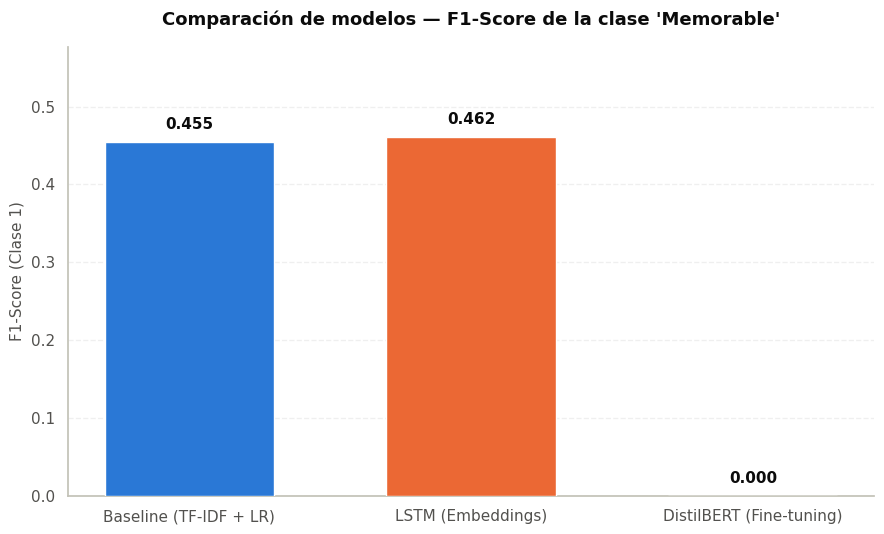


3) LECTURA DE LOS RESULTADOS
Mejor F1 (Clase 1) : LSTM (Embeddings) con 0.462
Peor F1 (Clase 1)  : DistilBERT (Fine-tuning) con 0.000
Amplitud entre extremos : 0.462
Mejor accuracy vs piso trivial : 0.583 vs 0.560 (+0.023)

BLOQUE 5c FINALIZADO: comparativa consolidada en 'df_comparativa'.


In [21]:
# =============================================================================
# BLOQUE 5c: EVALUACIÓN COMPARATIVA Y ANÁLISIS DE RESULTADOS
# =============================================================================
# Consolida en una sola vista los tres enfoques entrenados sobre EXACTAMENTE el
# mismo split estratificado, que es lo que vuelve legítima la comparación:
#   - Baseline    : TF-IDF + Regresión Logística  (Bloque 4)
#   - LSTM        : Embeddings aprendidos + LSTM  (Bloque 5a)
#   - DistilBERT  : Transformer pre-entrenado     (Bloque 5b)
#
# El foco está puesto en la CLASE 1 ('Memorable'), no en el accuracy global: es la
# clase minoritaria (44%) y la que realmente interesa detectar. Un modelo que
# predice siempre "no memorable" alcanza 55,96% de accuracy sin haber aprendido
# nada, de modo que el accuracy por sí solo puede ocultar un modelo inservible.
# =============================================================================

# -----------------------------------------------------------------------------
# 0. Importación de librerías
# -----------------------------------------------------------------------------
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import classification_report

# -----------------------------------------------------------------------------
# 1. CONSOLIDACIÓN DE MÉTRICAS
# -----------------------------------------------------------------------------
# El reporte del baseline se recalcula aquí a partir de las predicciones que
# quedaron en memoria en el Bloque 4, para que los tres modelos se extraigan de la
# misma estructura de datos y no haya riesgo de comparar métricas calculadas de
# formas distintas.
reporte_baseline = classification_report(
    y_test, y_pred, output_dict=True, zero_division=0
)


def extraer_metricas(nombre, reporte):
    """Aplana un classification_report a una fila de la tabla comparativa.

    Se toma la clase '1' ('Memorable') por ser la minoritaria y la de interés
    para el problema.
    """
    return {
        'Modelo': nombre,
        'Accuracy': reporte['accuracy'],
        'Precision (Clase 1)': reporte['1']['precision'],
        'Recall (Clase 1)': reporte['1']['recall'],
        'F1-Score (Clase 1)': reporte['1']['f1-score'],
    }


df_comparativa = pd.DataFrame([
    extraer_metricas('Baseline (TF-IDF + LR)', reporte_baseline),
    extraer_metricas('LSTM (Embeddings)', reporte_lstm),
    extraer_metricas('DistilBERT (Fine-tuning)', reporte_bert),
])

print("=" * 88)
print("1) TABLA COMPARATIVA DE MODELOS")
print("=" * 88)
print(df_comparativa.to_string(index=False, float_format=lambda v: f"{v:.3f}"))

# Referencia obligada: el piso que alcanza un clasificador trivial. Sin este
# número, cualquier accuracy cercano al 56% parece un resultado y no lo es.
print(f"\nPiso de referencia (predecir siempre la clase mayoritaria): {accuracy_mayoritaria:.3f}")
print("El F1-Score de la clase 'Memorable' de ese clasificador trivial es 0,000:")
print("nunca predice la clase positiva, de modo que no recupera un solo caso.")

# -----------------------------------------------------------------------------
# 2. VISUALIZACIÓN COMPARATIVA
# -----------------------------------------------------------------------------
# Forma elegida: barras. La tarea es comparar la MAGNITUD de una única métrica
# entre tres categorías nominales, que es exactamente para lo que sirven las
# barras (longitud desde una línea base común, el canal perceptual más preciso).
#
# Decisiones de diseño:
#   - Una sola métrica en pantalla -> no hace falta leyenda: el eje x ya nombra
#     cada modelo y el título nombra la métrica.
#   - Etiqueta de valor sobre cada barra: son sólo tres, de modo que rotularlas
#     todas no genera ruido y evita que el lector tenga que estimar contra la grilla.
#   - Grilla y ejes recesivos: la tinta debe estar en los datos, no en el marco.
#   - El eje y arranca en 0. Truncarlo exageraría visualmente diferencias chicas,
#     que es el error más común en este tipo de gráfico.
COLORES = ['#2a78d6', '#eb6834', '#1baf7a']  # paleta categórica, orden fijo

fig, ax = plt.subplots(figsize=(9, 5.5))

barras = ax.bar(
    df_comparativa['Modelo'],
    df_comparativa['F1-Score (Clase 1)'],
    color=COLORES,
    width=0.6,
    zorder=3
)

# Etiqueta directa sobre cada barra.
for barra, valor in zip(barras, df_comparativa['F1-Score (Clase 1)']):
    ax.text(
        barra.get_x() + barra.get_width() / 2,
        barra.get_height() + 0.012,
        f'{valor:.3f}',
        ha='center', va='bottom',
        fontsize=11, fontweight='bold',
        color='#0b0b0b'  # tinta, nunca el color de la serie
    )

ax.set_title("Comparación de modelos — F1-Score de la clase 'Memorable'",
             fontsize=13, fontweight='bold', pad=16, color='#0b0b0b')
ax.set_ylabel('F1-Score (Clase 1)', fontsize=11, color='#52514e')
ax.set_xlabel('')
ax.set_ylim(0, max(df_comparativa['F1-Score (Clase 1)'].max() * 1.25, 0.1))

# Marco recesivo: se quitan los bordes superiores y laterales, y la grilla queda
# por detrás de las barras (zorder) y en un gris tenue.
ax.grid(axis='y', linestyle='--', alpha=0.3, zorder=0)
ax.grid(axis='x', visible=False)
for lado in ['top', 'right']:
    ax.spines[lado].set_visible(False)
ax.spines['left'].set_color('#c3c2b7')
ax.spines['bottom'].set_color('#c3c2b7')
ax.tick_params(colors='#52514e')

plt.tight_layout()
plt.show()

# -----------------------------------------------------------------------------
# 3. LECTURA DE LOS RESULTADOS
# -----------------------------------------------------------------------------
mejor = df_comparativa.loc[df_comparativa['F1-Score (Clase 1)'].idxmax()]
peor = df_comparativa.loc[df_comparativa['F1-Score (Clase 1)'].idxmin()]
amplitud = mejor['F1-Score (Clase 1)'] - peor['F1-Score (Clase 1)']

print("\n" + "=" * 88)
print("3) LECTURA DE LOS RESULTADOS")
print("=" * 88)
print(f"Mejor F1 (Clase 1) : {mejor['Modelo']} con {mejor['F1-Score (Clase 1)']:.3f}")
print(f"Peor F1 (Clase 1)  : {peor['Modelo']} con {peor['F1-Score (Clase 1)']:.3f}")
print(f"Amplitud entre extremos : {amplitud:.3f}")
print(f"Mejor accuracy vs piso trivial : {df_comparativa['Accuracy'].max():.3f} vs {accuracy_mayoritaria:.3f} "
      f"({df_comparativa['Accuracy'].max() - accuracy_mayoritaria:+.3f})")

print("\n" + "=" * 88)
print("BLOQUE 5c FINALIZADO: comparativa consolidada en 'df_comparativa'.")
print("=" * 88)

In [20]:
# =============================================================================
# DIAGNÓSTICO: ¿puede este entorno correr el fine-tuning real de DistilBERT?
# =============================================================================
# Celda independiente y NO destructiva: no toca df_unificado ni ninguna variable
# de los bloques anteriores. Verifica un eslabón por vez y, si algo falla, dice
# cuál es y cómo se arregla. Ejecutar ANTES del Bloque 5b.
# =============================================================================
import inspect
import traceback

print("=" * 78)
print("DIAGNÓSTICO DE ENTORNO PARA DistilBERT")
print("=" * 78)

fallas = []


def verificar(nombre, funcion, critico=True):
    """Ejecuta una comprobación y reporta el resultado sin cortar la celda."""
    try:
        resultado = funcion()
        print(f"[OK]     {nombre}: {resultado}")
        return resultado
    except Exception as excepcion:
        print(f"[FALLA]  {nombre}: {type(excepcion).__name__}: {str(excepcion)[:180]}")
        if critico:
            fallas.append(nombre)
        return None


# --- 1. Librerías instaladas ------------------------------------------------
print("\n--- 1. LIBRERÍAS ---")


def version_de(paquete):
    modulo = __import__(paquete)
    return modulo.__version__


for paquete in ['torch', 'transformers', 'datasets', 'accelerate']:
    verificar(f"{paquete} instalado", lambda p=paquete: version_de(p))

# --- 2. Hardware ------------------------------------------------------------
print("\n--- 2. HARDWARE ---")


def estado_gpu():
    import torch
    if torch.cuda.is_available():
        return f"GPU disponible -> {torch.cuda.get_device_name(0)}"
    return "sin GPU (funciona igual en CPU, sólo más lento)"


verificar("Aceleración", estado_gpu, critico=False)

# --- 3. Conectividad con HuggingFace ---------------------------------------
print("\n--- 3. CONECTIVIDAD ---")


def alcanza_hub():
    import urllib.request
    url = 'https://huggingface.co/distilbert-base-uncased/resolve/main/config.json'
    with urllib.request.urlopen(url, timeout=30) as respuesta:
        return f"huggingface.co alcanzable (HTTP {respuesta.status})"


verificar("Acceso a huggingface.co", alcanza_hub)

# --- 4. Descarga real del checkpoint ----------------------------------------
print("\n--- 4. DESCARGA DEL MODELO REAL ---")
MODEL_NAME = 'distilbert-base-uncased'


def bajar_tokenizer():
    from transformers import AutoTokenizer
    global tok_diag
    tok_diag = AutoTokenizer.from_pretrained(MODEL_NAME)
    return f"{tok_diag.__class__.__name__}, vocabulario de {tok_diag.vocab_size:,} tokens"


def bajar_modelo():
    from transformers import AutoModelForSequenceClassification
    global mod_diag
    mod_diag = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)
    parametros = sum(p.numel() for p in mod_diag.parameters())
    return f"{mod_diag.__class__.__name__}, {parametros:,} parámetros"


verificar("Tokenizador", bajar_tokenizer)
verificar("Modelo", bajar_modelo)

# --- 5. Nombres de parámetros según la versión instalada --------------------
print("\n--- 5. API DE LA VERSIÓN INSTALADA ---")


def nombres_api():
    from transformers import Trainer, TrainingArguments
    ta = inspect.signature(TrainingArguments.__init__).parameters
    tr = inspect.signature(Trainer.__init__).parameters
    clave_eval = 'eval_strategy' if 'eval_strategy' in ta else 'evaluation_strategy'
    clave_tok = 'processing_class' if 'processing_class' in tr else 'tokenizer'
    return f"usar '{clave_eval}' y '{clave_tok}'"


verificar("Parámetros correctos", nombres_api)

# --- 6. Prueba de fuego con DATOS REALES ------------------------------------
# Entrena 1 época sobre una muestra chica del corpus real. Si esto pasa, el
# Bloque 5b completo va a funcionar: recorre exactamente el mismo camino.
print("\n--- 6. PRUEBA DE FUEGO (datos reales, muestra chica) ---")


def prueba_de_fuego():
    import numpy as np
    from datasets import Dataset
    from transformers import Trainer, TrainingArguments

    if 'tok_diag' not in globals() or 'mod_diag' not in globals():
        raise RuntimeError("omitida: depende de la descarga del paso 4, que no se completó")
    if 'df_unificado' not in globals():
        raise RuntimeError("df_unificado no está en memoria: ejecutá antes los Bloques 1 a 3")
    if 'cc_clean' not in df_unificado.columns:
        raise RuntimeError("falta la columna 'cc_clean': ejecutá antes el Bloque 3")

    muestra = df_unificado.head(32)
    datos = Dataset.from_dict({
        'text': muestra['cc_clean'].tolist(),
        'labels': muestra['memorable'].tolist()
    })
    datos = datos.map(
        lambda lote: tok_diag(lote['text'], truncation=True,
                              padding='max_length', max_length=55),
        batched=True
    )

    ta = inspect.signature(TrainingArguments.__init__).parameters
    argumentos = dict(
        output_dir='./diag_bert',
        num_train_epochs=1,
        per_device_train_batch_size=8,
        per_device_eval_batch_size=8,
        learning_rate=2e-5,
        report_to='none',
        save_strategy='no',
        logging_steps=1000
    )
    argumentos['eval_strategy' if 'eval_strategy' in ta else 'evaluation_strategy'] = 'no'

    kwargs_trainer = dict(model=mod_diag, args=TrainingArguments(**argumentos),
                          train_dataset=datos)
    tr = inspect.signature(Trainer.__init__).parameters
    kwargs_trainer['processing_class' if 'processing_class' in tr else 'tokenizer'] = tok_diag

    entrenador = Trainer(**kwargs_trainer)
    entrenador.train()
    salida = entrenador.predict(datos)
    predichas = np.argmax(salida.predictions, axis=1)
    return f"entrenó y predijo sobre {len(predichas)} ejemplos reales"


verificar("Fine-tuning end-to-end", prueba_de_fuego)

# --- 7. Veredicto -----------------------------------------------------------
print("\n" + "=" * 78)
if not fallas:
    print("VEREDICTO: entorno apto. El Bloque 5b va a correr con el modelo real.")
else:
    print(f"VEREDICTO: {len(fallas)} comprobación(es) fallaron -> {fallas}")
    print("\nSoluciones habituales:")
    print("  - Falta una librería      : !pip install -q transformers datasets accelerate")
    print("  - 'accelerate' desactualizado : !pip install -q -U 'accelerate>=1.1.0' y reiniciar el entorno")
    print("  - huggingface.co inalcanzable : la red del entorno lo bloquea. En Colab suele")
    print("    resolverse reiniciando el entorno de ejecución; si persiste, es la política")
    print("    de red y no hay arreglo desde el notebook.")
    print("  - df_unificado ausente    : ejecutá los Bloques 1 a 3 antes de esta celda.")
print("=" * 78)

DIAGNÓSTICO DE ENTORNO PARA DistilBERT

--- 1. LIBRERÍAS ---
[OK]     torch instalado: 2.11.0+cu128
[OK]     transformers instalado: 5.13.1
[OK]     datasets instalado: 4.0.0
[OK]     accelerate instalado: 1.14.0

--- 2. HARDWARE ---
[OK]     Aceleración: GPU disponible -> Tesla T4

--- 3. CONECTIVIDAD ---
[OK]     Acceso a huggingface.co: huggingface.co alcanzable (HTTP 200)

--- 4. DESCARGA DEL MODELO REAL ---
[OK]     Tokenizador: BertTokenizer, vocabulario de 30,522 tokens


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


[OK]     Modelo: DistilBertForSequenceClassification, 66,955,010 parámetros

--- 5. API DE LA VERSIÓN INSTALADA ---
[OK]     Parámetros correctos: usar 'eval_strategy' y 'processing_class'

--- 6. PRUEBA DE FUEGO (datos reales, muestra chica) ---


Map:   0%|          | 0/32 [00:00<?, ? examples/s]

Step,Training Loss


[OK]     Fine-tuning end-to-end: entrenó y predijo sobre 32 ejemplos reales

VEREDICTO: entorno apto. El Bloque 5b va a correr con el modelo real.
